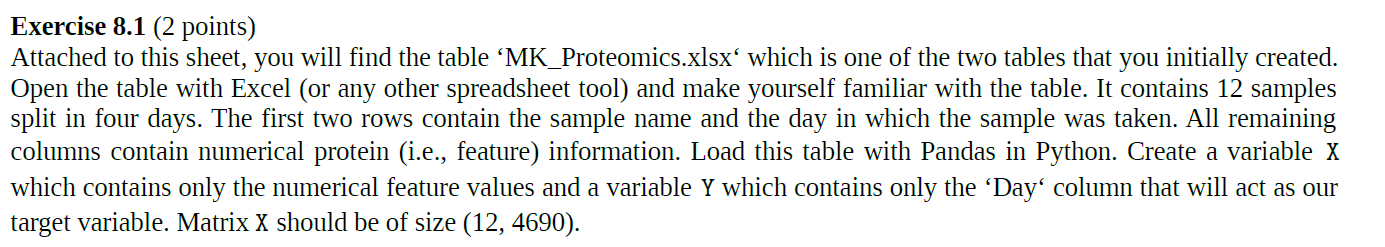

In [ ]:
import pandas as pd
df = pd.read_excel('MK_Proteomics.xlsx')
print(df)


X = df.drop(columns= ['Uniprot Accession', 'Day'])
Y = df.loc[:, "Day"]

print(X)
print(Y)

     Uniprot Accession    Day         Q921I1        P01592         Q62230  \
0   LFQ intensity d0_A  day 0  353634.621828  1.564424e+06  414410.203626   
1   LFQ intensity d0_B  day 0  455155.503648  1.239219e+06  542739.355262   
2   LFQ intensity d0_D  day 0  384493.584336  7.096755e+05  624395.234120   
3   LFQ intensity d1_B  day 1     830.352438  7.442647e+03   12618.038173   
4   LFQ intensity d1_C  day 1    8462.099886  3.216045e+04   39861.268468   
5   LFQ intensity d1_D  day 1   11256.728633  1.009933e+05   16810.791128   
6   LFQ intensity d3_B  day 3     216.780323  7.160775e+03   40180.280078   
7   LFQ intensity d3_C  day 3   12149.421496  1.309565e+04   35190.539219   
8   LFQ intensity d3_D  day 3    7207.583849  3.431920e+03   56528.860688   
9   LFQ intensity d7_A  day 7     391.210152  7.183643e+03   74291.008997   
10  LFQ intensity d7_B  day 7    1353.331916  7.318336e+03   93261.886995   
11  LFQ intensity d7_C  day 7    6412.627988  1.105338e+04  103051.072915   

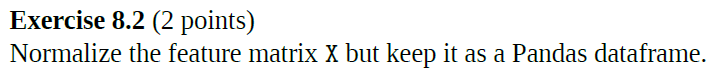

In [ ]:
from sklearn.preprocessing import StandardScaler

x = StandardScaler().fit_transform(X) # Cross check of the normalization

# Use standard NumPy array indexing instead of .iloc
print(x[:,0].mean(), x[:,0].std())

1.1102230246251565e-16 1.0000000000000002


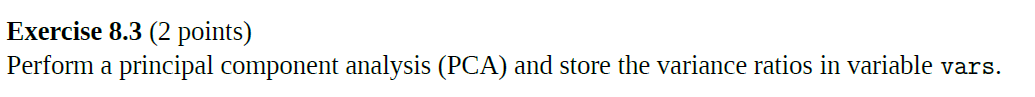

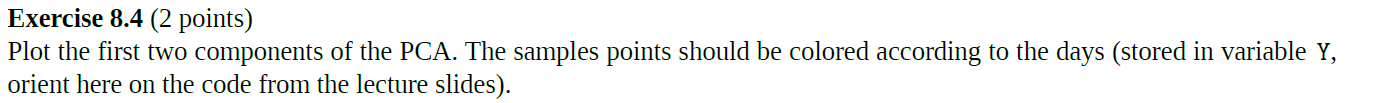

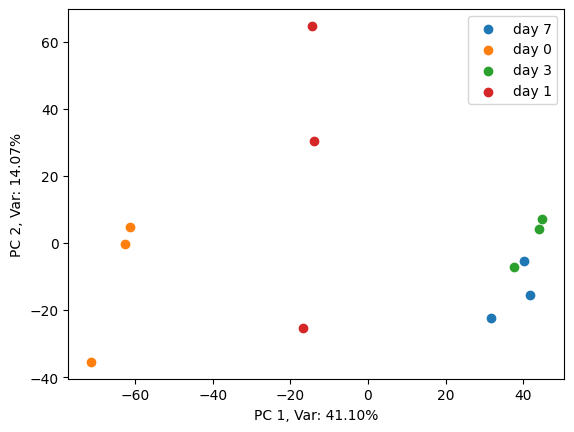

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA() # optional parameter: n_components = 5
components = pca.fit_transform(x)

xx, yy = components[:, 0], components[:, 1]
vars = pca.explained_variance_ratio_
for val in set(Y):
      plt.scatter(xx[Y == val], yy[Y == val], label=val)

plt.xlabel("PC 1, Var: %0.2f%%" % (vars[0] * 100))
plt.ylabel("PC 2, Var: %0.2f%%" % (vars[1] * 100))
plt.legend()
plt.show()

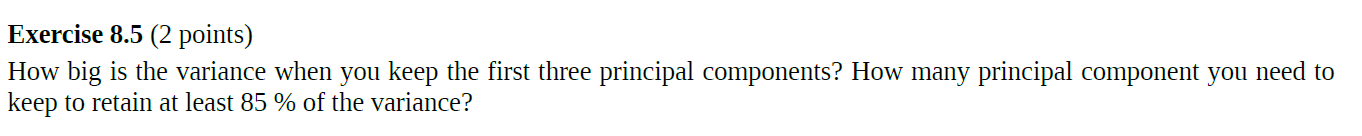

In [ ]:
import numpy as np

variance_first_3 = np.sum(vars[:3])
print(f"Variance first 3 PC: {variance_first_3 * 100}%")

#85 % Varianz?
cumulative_variance = np.cumsum(vars)
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1
print(f"PCs Number for > 85 % Variance: {n_components_85}")

Variance first 3 PC: 66.35519048617826%
PCs Number for > 85 % Variance: 6
